# 1. 분석 목표

# 2. 분석 세팅

In [101]:
# ▶ 설치
%pip install koreanize_matplotlib -q

# ▶ Warnings 제거
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

# 3. 데이터 불러오기

## 소비자

In [103]:
customers = pd.read_csv('data/olist_customers_dataset.csv')

In [104]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


## 판매자

In [105]:
sellers = pd.read_csv('data/olist_sellers_dataset.csv')

In [106]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


## 상품

In [107]:
# 상품
products = pd.read_csv('data/olist_products_dataset.csv')
product_category_name_translation = pd.read_csv('data/product_category_name_translation.csv')

In [108]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [109]:
product_category_name_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


## 주문

In [110]:
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

In [111]:
# 날짜 형식으로 변경
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [112]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [113]:
# 날짜 형식으로 변경
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [114]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [115]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [116]:
# 날짜 형식으로 변경
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

In [117]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


# 4. 데이터 설명

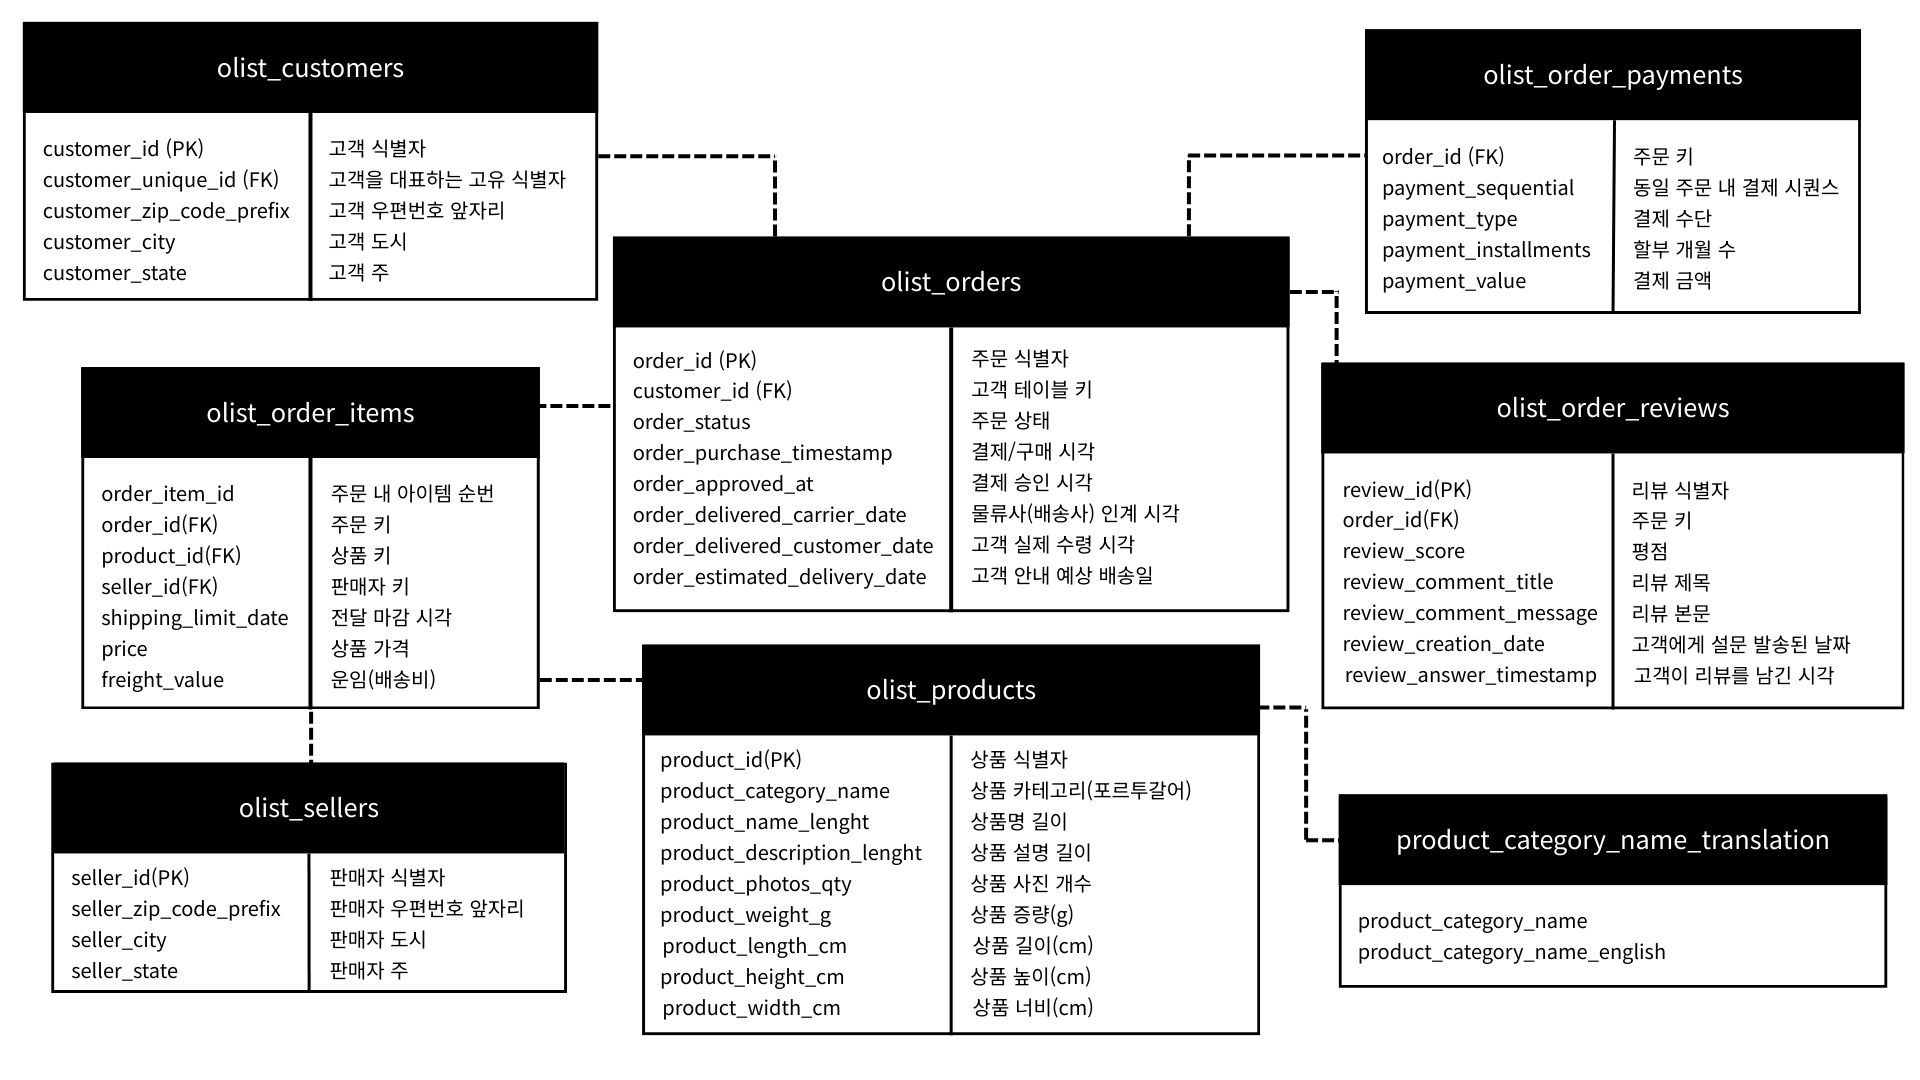

# 5. SQL 탐색 기반 데이터 정합성 문제 해결

## Case1: orders의 customer_id를 customers의 customer_unique_id로 대체

In [118]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [119]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [120]:
# 고유한 소비자 수: 96,096명
len(customers['customer_unique_id'].unique())

96096

In [121]:
# customer_unique_id가 중복되는 경우: 6,342건
print(sum(customers['customer_unique_id'].duplicated(keep=False)))

# 위 경우 중 주소지(도시 + 주)가 다른 경우: 234건
print(sum(customers.loc[:, ['customer_unique_id', 'customer_city', 'customer_state']].duplicated(keep=False)))

6342
6108


In [122]:
# 주소지가 다른 경우 확인
case1_condition1 = customers['customer_unique_id'].duplicated(keep=False) & ~(customers.loc[:, ['customer_unique_id', 'customer_city', 'customer_state']].duplicated(keep=False))

# 주소지가 다른 소비자는 121명 (총 234행)
# 전체 소비자 중 약 0.1% -> 제거
print(len(customers[case1_condition1]['customer_unique_id'].unique()))
customers[case1_condition1].sort_values(by='customer_unique_id').head()

121


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
91727,483468a56a54dbbbf8f2b2354cc8a729,0178b244a5c281fb2ade54038dd4b161,12518,guaratingueta,SP
57218,ea6ba2b2e27f7efea73bdeab7fd6e4a0,0178b244a5c281fb2ade54038dd4b161,14960,novo horizonte,SP
21682,caded193e8e47b8362864762a83db3c5,08fb46d35bb3ab4037202c23592d1259,13215,jundiai,SP
90484,ebc513ad3aed97e53c11e0e773c10152,08fb46d35bb3ab4037202c23592d1259,3220,sao paulo,SP
57793,1b4d105211b13b833f020c713d4bb56f,09d74edf20acb4f9523fb1cf19a18456,30441,belo horizonte,MG


In [123]:
customers_v1 = customers[~case1_condition1]
customers_v1.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [124]:
# 우편번호 컬럼 제거
customers_v2 = customers_v1[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']]
customers_v2.head()

,customer_id,customer_unique_id,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP


In [125]:
order_with_customer_col = [
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'customer_unique_id',
    'customer_city',
    'customer_state'
    ]

order_with_customer = pd.merge(orders, customers_v2, how='inner', on='customer_id')[order_with_customer_col]
order_with_customer.head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


## Case2: order_items 데이터셋 여러 행으로 표현하지말고 하나의 행으로 표현

In [126]:
# 112,650행
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [127]:
# 중복되는 행 제거
order_items_v1 = order_items.groupby(['order_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']).count().reset_index()
order_items_v1.rename(columns={'order_item_id': 'order_count'}, inplace=True)

In [128]:
# 102,425행
order_items_v1

,order_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_count
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,1
...,...,...,...,...,...,...,...
102420,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,1
102421,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,1
102422,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,1
102423,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,1


In [129]:
# 한 번의 주문에 여러 상품을 주문한 경우 -> 3,236건
order_product_count = order_items_v1.groupby(['order_id']).agg({'product_id': 'count'}).reset_index().rename(columns={'product_id': 'count'})
one_order_many_product = order_product_count[order_product_count['count'] > 1]
one_order_many_product.sort_values('count', ascending=False)

,order_id,count
77909,ca3625898fbd48669d50701aba51cd5f,8
46116,77df84f9195be22a4e9cb72ca9e8b4c2,7
66653,ad850e69fce9a512ada84086651a2e7d,7
48309,7d8f5bfd5aff648220374a2df62e84d5,7
13955,2455cbeb73fd04b170ca2504662f95ce,6
...,...,...
34975,5b004e91449a77cd4ad0a10e8fdac668,2
34982,5b02e3190400ea2755927d0ee0647d73,2
35044,5b2c9910c96e7dec4dac98d009a43858,2
35053,5b33244d158adb23abb0d481fa052af8,2


## Case3: order_payments 데이터셋에서 payment_type이 not_defined인 경우 3건 -> 제거

In [130]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [131]:
order_payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [132]:
# 결제 수단이 not_defined인 경우 제거
# 제거 후: 103,883건
order_payments_v1 = order_payments[order_payments['payment_type'] != 'not_defined']
order_payments_v1.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [133]:
order_payments_v2 = order_payments_v1.groupby(['order_id', 'payment_type']).agg({'payment_installments': 'mean', 'payment_value': 'sum'}).reset_index()
order_payments_v2['payment_installments'] = order_payments_v2['payment_installments'].astype('int')
order_payments_v2

,order_id,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,credit_card,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,credit_card,3,259.83
2,000229ec398224ef6ca0657da4fc703e,credit_card,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,credit_card,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,credit_card,3,218.04
...,...,...,...,...
101678,fffc94f6ce00a00581880bf54a75a037,boleto,1,343.40
101679,fffcd46ef2263f404302a634eb57f7eb,boleto,1,386.53
101680,fffce4705a9662cd70adb13d4a31832d,credit_card,3,116.85
101681,fffe18544ffabc95dfada21779c9644f,credit_card,3,64.71


In [134]:
# 분할 결제한 주문: 2,246건
order_payments_check = order_payments_v2[order_payments_v2['order_id'].isin(order_payments_v2['order_id'].value_counts()[order_payments_v2['order_id'].value_counts() > 1].index)].sort_values(by='order_id')
len(order_payments_check['order_id'].unique())

2246

## Case4: 한 주문에 여러 리뷰가 있는 경우 존재. 어떤 리뷰를 남겨야할까 (데이터셋을 모두 합칠 때는 하나만 남기는게 좋음)
- orders에 있는 review만 남기고 나머지는 제거 -> 231건 제거
- 상품 수령 후, 리뷰를 남긴 시점에 따라 또 비교를 하기 위해 합치지 않고 일단 따로 보관 -> order_reviews_v1

In [135]:
# 99,224행
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [136]:
len(order_reviews['order_id'].unique())

98673

In [137]:
len(order_with_customer['order_id'].unique())

99207

In [138]:
# 98,993행
order_reviews_v1 = order_reviews[order_reviews['order_id'].isin(order_with_customer['order_id'].unique())].reset_index(drop=True)
order_reviews_v1.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


## Case5: order_reviews 데이터셋에서 review_creation_date나 review_answer_timestamp가 올바르지 않은 날짜/시간 형식으로 된 경우 확인

In [139]:
order_reviews_v1.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [140]:
order_reviews_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98993 entries, 0 to 98992
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                98993 non-null  object        
 1   order_id                 98993 non-null  object        
 2   review_score             98993 non-null  int64         
 3   review_comment_title     11542 non-null  object        
 4   review_comment_message   40897 non-null  object        
 5   review_creation_date     98993 non-null  datetime64[ns]
 6   review_answer_timestamp  98993 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [141]:
str_review_creation_date = order_reviews_v1['review_creation_date'].astype(str).str.strip().str.split().str[0]

# 정확히 YYYY-MM-DD 인 것만 허용
mask_bad = str_review_creation_date.ne('') & ~str_review_creation_date.str.match(r'^\d{4}-\d{2}-\d{2}$')

print('형식 불일치 개수:', mask_bad.sum())

형식 불일치 개수: 0


In [142]:
str_review_answer_timestamp = order_reviews_v1['review_answer_timestamp'].astype(str).str.strip()

# 정확히 YYYY-MM-DD HH:MM:SS 인 것만 허용
mask_bad = str_review_answer_timestamp.ne('') & ~str_review_answer_timestamp.str.match(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$')

print('형식 불일치 개수:', mask_bad.sum())

형식 불일치 개수: 0


In [143]:
# review_creation_date 전에 리뷰가 달린 경우 없음
len(order_reviews_v1[order_reviews_v1['review_creation_date'] > order_reviews_v1['review_answer_timestamp']])

0

## Case6: products 데이터셋의 product_category_name을 product_category_name_translation의 product_category_name_english로 대체

In [144]:
products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [145]:
product_category_name_translation

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [146]:
# product_category_name이 없는 상품도 존재 -> 623건 제거
products_v1 = pd.merge(products, product_category_name_translation, how='inner', on='product_category_name')
products_v1

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,6a2fb4dd53d2cdb88e0432f1284a004c,perfumaria,39.0,346.0,2.0,400.0,27.0,5.0,20.0,perfumery
2,0d009643171aee696f4733340bc2fdd0,perfumaria,52.0,150.0,1.0,422.0,21.0,16.0,18.0,perfumery
3,b1eae565a61935e0011ee7682fef9dc9,perfumaria,49.0,460.0,2.0,267.0,17.0,13.0,17.0,perfumery
4,8da90b37f0fb171b4877c124f965b1f6,perfumaria,56.0,733.0,3.0,377.0,18.0,13.0,15.0,perfumery
...,...,...,...,...,...,...,...,...,...,...
32323,13b25797ad1e6d6c7cd3cbeb35f8ee7a,moveis_colchao_e_estofado,44.0,348.0,1.0,18250.0,25.0,25.0,25.0,furniture_mattress_and_upholstery
32324,dc36a7859b743d8610a2bbbaea26ece9,moveis_colchao_e_estofado,29.0,2073.0,2.0,2500.0,41.0,21.0,21.0,furniture_mattress_and_upholstery
32325,107fde0930956120d1e13dd1062fbb46,moveis_colchao_e_estofado,51.0,418.0,1.0,30000.0,60.0,73.0,60.0,furniture_mattress_and_upholstery
32326,726b4e18f00255e2e63491bcba3f60b8,moveis_colchao_e_estofado,41.0,866.0,1.0,1700.0,70.0,10.0,100.0,furniture_mattress_and_upholstery


## Case7: order_items에 products, sellers 정보 추가

In [147]:
order_items_v2 = pd.merge(order_items_v1, products_v1, how='inner', on='product_id')
order_items_v2

,order_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_count,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,1,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,130898c0987d1801452a8ed92a670612,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-07-05 02:44:11,55.9,17.96,1,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
2,532ed5e14e24ae1f0d735b91524b98b9,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2018-05-23 10:56:25,64.9,18.33,1,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
3,6f8c31653edb8c83e1a739408b5ff750,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-08-07 18:55:08,58.9,16.17,1,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
4,7d19f4ef4d04461989632411b7e588b9,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-08-16 22:05:11,58.9,13.29,1,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100938,ffebd80e3291e811c308365936897efd,4cc4d02efc8f249c13355147fb44e34d,d1c7fa84e48cfa21a0e595167c1c500e,2018-07-18 20:23:55,129.9,51.20,1,ferramentas_jardim,37.0,653.0,1.0,6700.0,35.0,12.0,22.0,garden_tools
100939,ffee31fb4b5e35c9123608015637c495,b10ecf8e33aaaea419a9fa860ea80fb5,0241d4d5d36f10f80c644447315af0bd,2018-08-21 10:10:11,99.0,13.52,1,moveis_decoracao,30.0,308.0,1.0,2300.0,37.0,30.0,20.0,furniture_decor
100940,fff7c4452f050315db1b3f24d9df5fcd,dd469c03ad67e201bc2179ef077dcd48,7e93a43ef30c4f03f38b393420bc753a,2017-06-07 17:05:23,736.0,20.91,1,relogios_presentes,33.0,658.0,3.0,400.0,19.0,9.0,15.0,watches_gifts
100941,fffa82886406ccf10c7b4e35c4ff2788,bbe7651fef80287a816ead73f065fc4b,8f2ce03f928b567e3d56181ae20ae952,2017-12-22 17:31:42,229.9,44.02,1,esporte_lazer,32.0,280.0,2.0,2700.0,60.0,15.0,15.0,sports_leisure


In [148]:
order_items_v3_col = ['order_id', 'shipping_limit_date', 'price', 'freight_value', 'order_count',
                      'product_id', 'product_category_name_english', 'product_name_lenght', 'product_description_lenght',
                      'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
                      'seller_id', 'seller_city', 'seller_state']

order_items_v3 = pd.merge(order_items_v2, sellers, how='inner', on='seller_id')[order_items_v3_col]
order_items_v3

,order_id,shipping_limit_date,price,freight_value,order_count,product_id,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-19 09:45:35,58.90,13.29,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
1,130898c0987d1801452a8ed92a670612,2017-07-05 02:44:11,55.90,17.96,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
2,532ed5e14e24ae1f0d735b91524b98b9,2018-05-23 10:56:25,64.90,18.33,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
3,6f8c31653edb8c83e1a739408b5ff750,2017-08-07 18:55:08,58.90,16.17,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
4,7d19f4ef4d04461989632411b7e588b9,2017-08-16 22:05:11,58.90,13.29,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100938,fd607d0a02cb276bc764a15f80f0423f,2018-08-02 02:24:15,171.39,19.35,2,02ad78835ec3f72e750d1dfa6a7e11b3,furniture_decor,38.0,1303.0,2.0,1250.0,52.0,7.0,11.0,2a73cba571d90c694b7caca072ccf6ce,sao caetano do sul,SP
100939,fdaf98feac227eb978d8f33f36e0231d,2017-04-27 05:10:28,119.90,16.14,1,f739e9151702508b18f796c53005e5e9,furniture_decor,44.0,533.0,2.0,1000.0,69.0,11.0,11.0,d1aa1ec0839dcab73a6161130eb1f94a,curitiba,PR
100940,fe68b52db13993f58175fa589125d345,2017-08-17 02:55:27,209.00,16.21,1,f4135cbdece8245560f7be179533797a,electronics,32.0,1306.0,3.0,500.0,17.0,9.0,25.0,3fefda3299e6dfaea3466ef346a3571a,curitiba,PR
100941,fefacc66af859508bf1a7934eab1e97f,2018-08-02 04:05:13,6729.00,193.21,1,69c590f7ffc7bf8db97190b6cb6ed62e,computers,50.0,1935.0,4.0,5660.0,54.0,18.0,47.0,80ceebb4ee9b31afb6c6a916a574a1e2,londrina,PR


## Case8: orders 날짜 상태가 논리적으로 순서에 맞게 되어 있는지 확인

In [149]:
order_with_customer.head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [150]:
166 / len(order_with_customer)

0.0016732690233552069

In [151]:
# 구매 이전에 배송사에 상품이 인계된 경우: 166건
# order_with_customer의 0.001%이기 때문에 제거
print(sum(order_with_customer['order_purchase_timestamp'] > order_with_customer['order_delivered_carrier_date']))
order_with_customer_v1 = order_with_customer[~(order_with_customer['order_purchase_timestamp'] > order_with_customer['order_delivered_carrier_date'])]

166


In [152]:
# 결제 승인 이전에 배송사에 상품이 인계된 경우: 1,188건
print('<결제 승인 이전에 배송사에 상품이 인계된 경우>')
print(sum(order_with_customer_v1['order_approved_at'] > order_with_customer_v1['order_delivered_carrier_date']))

# 결제 승인 이전에 고객에게 배달된 경우: 61건(모두 배달 완료)
print('<결제 승인 이전에 고객에게 상품이 배달된 경우>')
print(sum(order_with_customer_v1['order_approved_at'] > order_with_customer_v1['order_delivered_customer_date']))

<결제 승인 이전에 배송사에 상품이 인계된 경우>
1188
<결제 승인 이전에 고객에게 상품이 배달된 경우>
61


In [153]:
# 위의 경우 결제 승인 시점을 고객의 상품 구매 시각으로 변경
order_con_1 = order_with_customer_v1['order_approved_at'] > order_with_customer_v1['order_delivered_carrier_date']

order_with_customer_v1.loc[order_con_1, 'order_approved_at'] = order_with_customer_v1.loc[order_con_1, 'order_purchase_timestamp']

In [154]:
# 구매 시각 이전으로 예상 배달 날짜가 잡힌 경우: 0건
print('<구매 시각 이전으로 예상 배달 날짜가 잡힌 경우>')
sum(order_with_customer['order_purchase_timestamp'] > order_with_customer['order_estimated_delivery_date'])

<구매 시각 이전으로 예상 배달 날짜가 잡힌 경우>


0

In [155]:
# 구매 승인 시각 이전으로 예상 배달 날짜가 잡힌 경우: 12건
print('<구매 승인 시각 이전으로 예상 배달 날짜가 잡힌 경우>')
sum(order_with_customer['order_approved_at'] > order_with_customer['order_estimated_delivery_date'])

<구매 승인 시각 이전으로 예상 배달 날짜가 잡힌 경우>


12

In [156]:
# 위의 경우 결제 승인 시점을 고객의 상품 구매 시각으로 변경
order_con_2 = order_with_customer_v1['order_approved_at'] > order_with_customer_v1['order_estimated_delivery_date']

order_with_customer_v1.loc[order_con_2, 'order_approved_at'] = order_with_customer_v1.loc[order_con_2, 'order_purchase_timestamp']

In [157]:
# 배송사 인계 전에 고객에게 배달된 경우: 22건
print('<배송사 인계 전에 고객에게 배달된 경우>')
sum(order_with_customer['order_delivered_carrier_date'] > order_with_customer['order_delivered_customer_date'])

<배송사 인계 전에 고객에게 배달된 경우>


22

In [158]:
order_con_3 = order_with_customer_v1['order_delivered_carrier_date'] < order_with_customer_v1['order_delivered_customer_date']
order_with_customer_v1 = order_with_customer_v1[order_con_3].reset_index(drop=True)

## 최종 정합성 체크

In [159]:
order_with_customer_v1.head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [160]:
order_items_v3.head()

,order_id,shipping_limit_date,price,freight_value,order_count,product_id,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-19 09:45:35,58.9,13.29,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
1,130898c0987d1801452a8ed92a670612,2017-07-05 02:44:11,55.9,17.96,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
2,532ed5e14e24ae1f0d735b91524b98b9,2018-05-23 10:56:25,64.9,18.33,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
3,6f8c31653edb8c83e1a739408b5ff750,2017-08-07 18:55:08,58.9,16.17,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
4,7d19f4ef4d04461989632411b7e588b9,2017-08-16 22:05:11,58.9,13.29,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP


In [161]:
order_payments_v2.head()

,order_id,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,credit_card,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,credit_card,3,259.83
2,000229ec398224ef6ca0657da4fc703e,credit_card,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,credit_card,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,credit_card,3,218.04


In [162]:
order_reviews_v1.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [163]:
check_year_month = (order_with_customer_v1['order_purchase_timestamp'].dt.year == 2017) | ((order_with_customer_v1['order_purchase_timestamp'].dt.year == 2018) & (order_with_customer_v1['order_purchase_timestamp'].dt.month <= 8))
order_with_customer_v2 = order_with_customer_v1[check_year_month]

In [164]:
common_ids = set(order_with_customer_v2['order_id']).intersection(
    order_items_v3['order_id'],
    order_payments_v2['order_id'],
    order_reviews_v1['order_id']
)

len(common_ids)

93810

In [165]:
orders_final = order_with_customer_v1[order_with_customer_v1['order_id'].isin(common_ids)].reset_index(drop=True)
order_items_final = order_items_v3[order_items_v3['order_id'].isin(common_ids)].reset_index(drop=True)
order_payments_final = order_payments_v2[order_payments_v2['order_id'].isin(common_ids)].reset_index(drop=True)
order_reviews_final = order_reviews_v1[order_reviews_v1['order_id'].isin(common_ids)].reset_index(drop=True)

In [166]:
print('orders:', len(order_with_customer_v1), "→", len(orders_final))
print('order_items:', len(order_items_v3), "→", len(order_items_final))
print('order_payments:', len(order_payments_v2), "→", len(order_payments_final))
print('order_reviews:', len(order_reviews_v1), "→", len(order_reviews_final))

orders: 96055 → 93810
order_items: 100943 → 97357
order_payments: 101683 → 95924
order_reviews: 98993 → 94329


# 6. EDA (탐색적 데이터 분석)

## 정합성 문제 해결 후 사용할 데이터셋

### orders + customers

In [167]:
orders_final.head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [168]:
orders_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93810 entries, 0 to 93809
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       93810 non-null  object        
 1   order_status                   93810 non-null  object        
 2   order_purchase_timestamp       93810 non-null  datetime64[ns]
 3   order_approved_at              93797 non-null  datetime64[ns]
 4   order_delivered_carrier_date   93810 non-null  datetime64[ns]
 5   order_delivered_customer_date  93810 non-null  datetime64[ns]
 6   order_estimated_delivery_date  93810 non-null  datetime64[ns]
 7   customer_unique_id             93810 non-null  object        
 8   customer_city                  93810 non-null  object        
 9   customer_state                 93810 non-null  object        
dtypes: datetime64[ns](5), object(5)
memory usage: 7.2+ MB


### order_items + products + sellers

In [169]:
order_items_final.head()

,order_id,shipping_limit_date,price,freight_value,order_count,product_id,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-19 09:45:35,58.9,13.29,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
1,130898c0987d1801452a8ed92a670612,2017-07-05 02:44:11,55.9,17.96,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
2,532ed5e14e24ae1f0d735b91524b98b9,2018-05-23 10:56:25,64.9,18.33,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
3,6f8c31653edb8c83e1a739408b5ff750,2017-08-07 18:55:08,58.9,16.17,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
4,7d19f4ef4d04461989632411b7e588b9,2017-08-16 22:05:11,58.9,13.29,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP


In [170]:
order_items_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97357 entries, 0 to 97356
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       97357 non-null  object        
 1   shipping_limit_date            97357 non-null  datetime64[ns]
 2   price                          97357 non-null  float64       
 3   freight_value                  97357 non-null  float64       
 4   order_count                    97357 non-null  int64         
 5   product_id                     97357 non-null  object        
 6   product_category_name_english  97357 non-null  object        
 7   product_name_lenght            97357 non-null  float64       
 8   product_description_lenght     97357 non-null  float64       
 9   product_photos_qty             97357 non-null  float64       
 10  product_weight_g               97356 non-null  float64       
 11  product_length_

### order_payments

In [171]:
order_payments_final.head()

,order_id,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,credit_card,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,credit_card,3,259.83
2,000229ec398224ef6ca0657da4fc703e,credit_card,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,credit_card,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,credit_card,3,218.04


In [172]:
order_payments_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95924 entries, 0 to 95923
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              95924 non-null  object 
 1   payment_type          95924 non-null  object 
 2   payment_installments  95924 non-null  int32  
 3   payment_value         95924 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 2.6+ MB


### order_reviews

In [173]:
order_reviews_final.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [174]:
order_reviews_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94329 entries, 0 to 94328
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                94329 non-null  object        
 1   order_id                 94329 non-null  object        
 2   review_score             94329 non-null  int64         
 3   review_comment_title     11056 non-null  object        
 4   review_comment_message   38192 non-null  object        
 5   review_creation_date     94329 non-null  datetime64[ns]
 6   review_answer_timestamp  94329 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.0+ MB


## EDA 진행

### orders_final

In [175]:
orders_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93810 entries, 0 to 93809
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       93810 non-null  object        
 1   order_status                   93810 non-null  object        
 2   order_purchase_timestamp       93810 non-null  datetime64[ns]
 3   order_approved_at              93797 non-null  datetime64[ns]
 4   order_delivered_carrier_date   93810 non-null  datetime64[ns]
 5   order_delivered_customer_date  93810 non-null  datetime64[ns]
 6   order_estimated_delivery_date  93810 non-null  datetime64[ns]
 7   customer_unique_id             93810 non-null  object        
 8   customer_city                  93810 non-null  object        
 9   customer_state                 93810 non-null  object        
dtypes: datetime64[ns](5), object(5)
memory usage: 7.2+ MB


#### 월별 구매 횟수
- 2017년부터 꾸준히 성장하다가 성장세가 2018년에 정체된 모습

In [176]:
orders_final_year_month = orders_final.copy()
orders_final_year_month['year'] = orders_final_year_month['order_purchase_timestamp'].dt.year
orders_final_year_month['month'] = orders_final_year_month['order_purchase_timestamp'].dt.month

In [177]:
purchase_year_month = orders_final_year_month.groupby(['year', 'month']).agg({'order_id': 'count'}).reset_index()
purchase_year_month['year_month'] = purchase_year_month['year'].astype(str) + '-' + purchase_year_month['month'].astype(str).str.zfill(2)
purchase_year_month

,year,month,order_id,year_month
0,2017,1,724,2017-01
1,2017,2,1588,2017-02
2,2017,3,2472,2017-03
3,2017,4,2222,2017-04
4,2017,5,3420,2017-05
5,2017,6,3053,2017-06
6,2017,7,3775,2017-07
7,2017,8,4087,2017-08
8,2017,9,4046,2017-09
9,2017,10,4385,2017-10


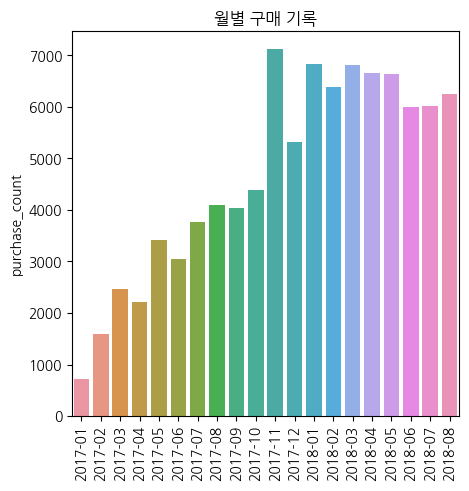

In [178]:
fig, ax = plt.subplots(figsize=(5,5))

sns.barplot(data=purchase_year_month, x='year_month', y='order_id')

ax.set_title('월별 구매 기록')
ax.set_xlabel('')
ax.set_ylabel('purchase_count')

plt.xticks(rotation=90)
plt.show()

#### 가장 주문을 많이 한 시간대
- 오전 10시에서 오후 10시 사이에 집중

In [179]:
orders_final_hour = orders_final.copy()
orders_final_hour['hour'] = orders_final['order_purchase_timestamp'].dt.hour

In [180]:
purchase_hour = orders_final_hour.groupby('hour').agg({'order_id': 'count'}).reset_index()
purchase_hour['hour'] = purchase_hour['hour'].astype(str) + '시'
purchase_hour

,hour,order_id
0,0시,2250
1,1시,1105
2,2시,475
3,3시,254
4,4시,196
5,5시,176
6,6시,465
7,7시,1164
8,8시,2840
9,9시,4524


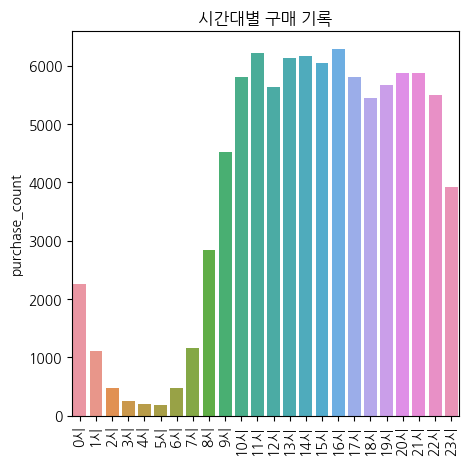

In [181]:
fig, ax = plt.subplots(figsize=(5,5))

sns.barplot(data=purchase_hour, x='hour', y='order_id')

ax.set_title('시간대별 구매 기록')
ax.set_xlabel('')
ax.set_ylabel('purchase_count')

plt.xticks(rotation=90)
plt.show()

#### 가장 구매를 많이 한 City, State
- City top3
    - sao paulo:브라질 최대 도시이자 남미 전체에서 가장 큰 경제 중심지. 금융, 산업, 상업, 기술 스타트업이 집중되어 있어 "브라질의 경제 수도"
    - rio de janeiro: 브라질의 대표 관광 도시. 코파카바나 해변, 슈가로프 산, 예수상(Cristo Redentor) 등 세계적인 랜드마크 위치
    - belo horizonte: 라질 제3의 대도시권을 이루는 내륙 도시. “아름다운 수평선”이라는 뜻의 이름처럼 계획도시로 개발된 곳

- State top3: 남동부의 세 주요 주이고, 브라질 경제·인구의 상당 부분이 집중된 핵심 지역
    - SP(São Paulo): 브라질에서 인구와 경제 규모가 가장 큰 주. 상파울루 시가 위치
    - RJ(Rio de Janeiro): 리우데자네이루 시가 위치한 주. 유명한 관광지(코파카바나, 예수상 등)
    - MG(Minas Gerais): 내륙 주로서 인구가 많고, 광업과 농업 중심. 브라질리아(연방 수도)와 인접

In [182]:
top30_city = pd.DataFrame(orders_final['customer_city'].value_counts().head(30)).reset_index()
top10_state = pd.DataFrame(orders_final['customer_state'].value_counts().head(10)).reset_index()

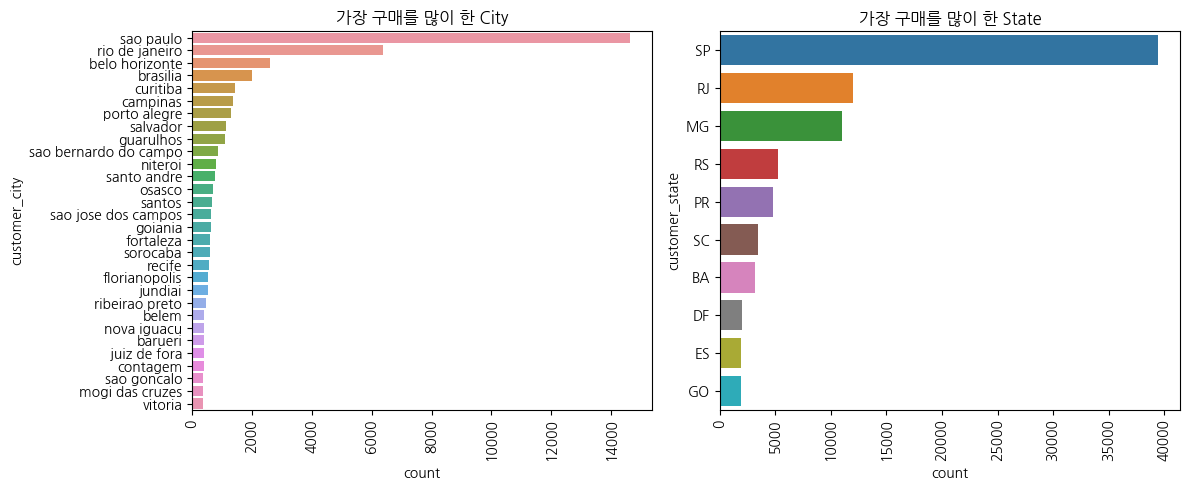

In [183]:
fig, ax = plt.subplots(figsize=(12,5), ncols=2)

sns.barplot(data=top30_city,  y='customer_city',  x='count', ax=ax[0])
sns.barplot(data=top10_state, y='customer_state', x='count', ax=ax[1])

ax[0].set_title('가장 구매를 많이 한 City')
ax[1].set_title('가장 구매를 많이 한 State')

# x축 라벨이 많을 경우 기울여 주면 보기 좋음
for a in ax:
    a.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

#### 결제 승인까지 걸린 시간
- 이상치 제거 전: 평균 9시간
- 이상치 제거 후: 평균 4시간

In [184]:
orders_final.head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [185]:
approval_delay_hour = (orders_final['order_approved_at'] - orders_final['order_purchase_timestamp']).dt.total_seconds() / 3600
approval_delay_hour.describe()

count    93797.000000
mean         9.501388
std         19.019031
min          0.000000
25%          0.211667
50%          0.331667
75%         13.083611
max        741.443611
dtype: float64

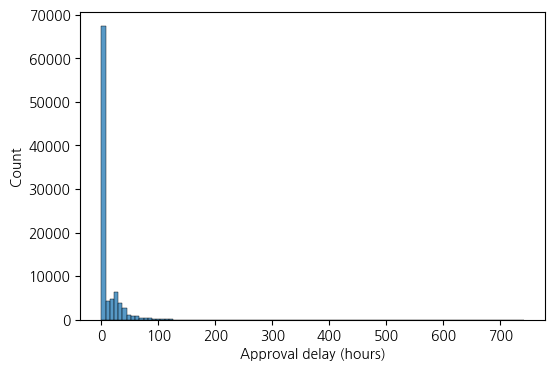

In [186]:
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(approval_delay_hour, bins=100)

ax.set_xlabel("Approval delay (hours)")
ax.set_ylabel("Count")
plt.show()

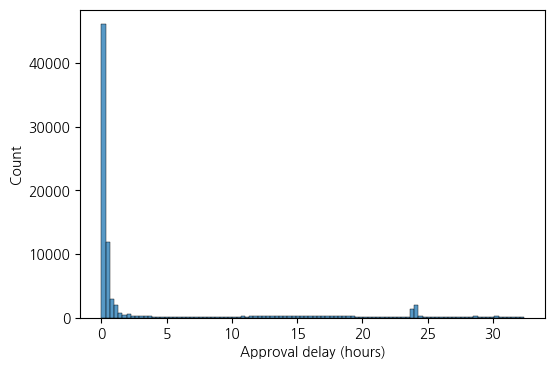

In [187]:
Q1 = approval_delay_hour.quantile(0.25)
Q3 = approval_delay_hour.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 이상치 제거
approval_delay_hour_filtered = approval_delay_hour[(approval_delay_hour >= lower) & (approval_delay_hour <= upper)]

fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(approval_delay_hour_filtered, bins=100, ax=ax)

ax.set_xlabel("Approval delay (hours)")
ax.set_ylabel("Count")
plt.show()

In [188]:
approval_delay_hour_filtered.describe()

count    84099.000000
mean         4.404806
std          8.410564
min          0.000000
25%          0.203889
50%          0.291944
75%          1.331667
max         32.391389
dtype: float64

#### 결제 승인부터 배송사에 인계되기까지 걸린 시간
- 이상치 제거 전: 평균 67시간
- 이상치 제거 후: 평균 52시간

In [189]:
delivered_carrier_hour = (orders_final['order_delivered_carrier_date'] - orders_final['order_approved_at']).dt.total_seconds() / 3600
delivered_carrier_hour.describe()

count    93797.000000
mean        67.060853
std         79.938931
min          0.004167
25%         21.459722
50%         43.880000
75%         85.187500
max       2569.277222
dtype: float64

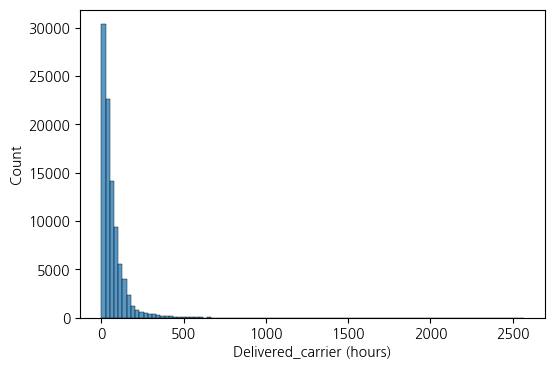

In [190]:
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(delivered_carrier_hour, bins=100)

ax.set_xlabel("Delivered_carrier (hours)")
ax.set_ylabel("Count")
plt.show()

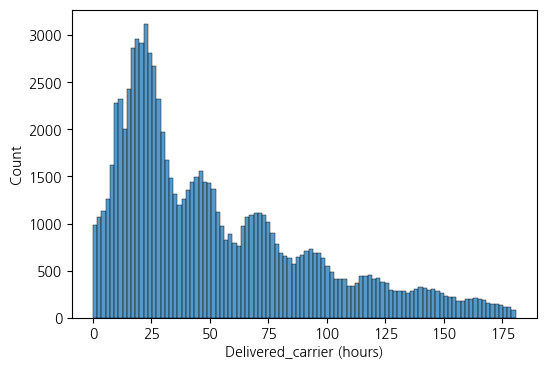

In [191]:
Q1 = delivered_carrier_hour.quantile(0.25)
Q3 = delivered_carrier_hour.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 이상치 제거
delivered_carrier_filtered = delivered_carrier_hour[(delivered_carrier_hour >= lower) & (delivered_carrier_hour <= upper)]

fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(delivered_carrier_filtered, bins=100, ax=ax)

ax.set_xlabel("Delivered_carrier (hours)")
ax.set_ylabel("Count")
plt.show()

In [192]:
delivered_carrier_filtered.describe()

count    88525.000000
mean        52.692840
std         41.256115
min          0.004167
25%         20.651667
50%         40.561944
75%         75.517222
max        180.737222
dtype: float64

#### 배송사에서 고객에게까지 걸린 시간
- 이상치 제거 전: 평균 223시간
- 이상치 제거 후: 평균 189시간

In [193]:
orders_final.columns

Index(['order_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_city', 'customer_state'],
      dtype='object')

In [195]:
delivered_customer_hour = (orders_final['order_delivered_customer_date'] - orders_final['order_delivered_carrier_date']).dt.total_seconds() / 3600
delivered_customer_hour.describe()

count    93810.000000
mean       223.515540
std        208.179408
min          0.000278
25%         98.629375
50%        170.423611
75%        288.594653
max       4924.583333
dtype: float64

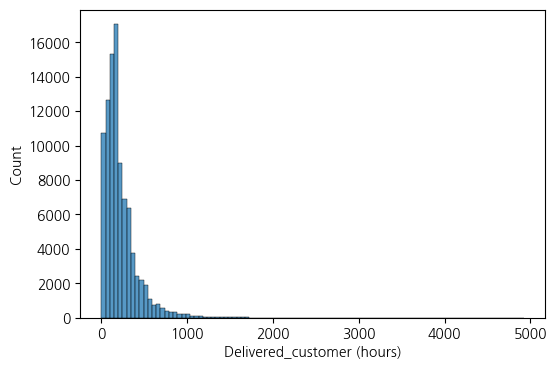

In [196]:
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(delivered_customer_hour, bins=100)

ax.set_xlabel("Delivered_customer (hours)")
ax.set_ylabel("Count")
plt.show()

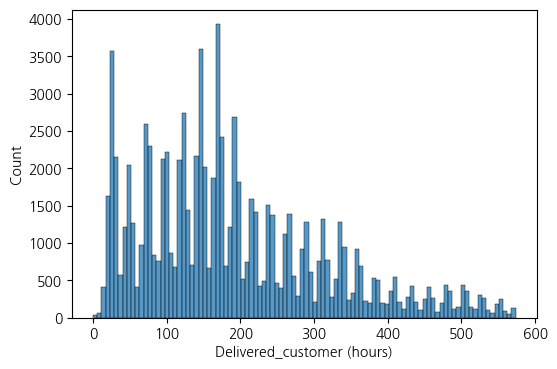

In [197]:
Q1 = delivered_customer_hour.quantile(0.25)
Q3 = delivered_customer_hour.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 이상치 제거
delivered_customer_filtered = delivered_customer_hour[(delivered_customer_hour >= lower) & (delivered_customer_hour <= upper)]

fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(delivered_customer_filtered, bins=100, ax=ax)

ax.set_xlabel("Delivered_customer (hours)")
ax.set_ylabel("Count")
plt.show()

In [198]:
delivered_customer_filtered.describe()

count    88932.000000
mean       189.650180
std        125.668100
min          0.000278
25%         96.071319
50%        167.096806
75%        263.446667
max        573.533056
dtype: float64

#### 고객이 주문한 이후로 배송을 받는데까지 걸린 시간

In [226]:
total_delivered_hour = (delivered_carrier_hour + approval_delay_hour + delivered_customer_hour)
total_delivered_hour.describe()

count    93797.000000
mean       300.079742
std        226.675110
min         12.801944
25%        162.154722
50%        244.858889
75%        375.036389
max       5000.442222
dtype: float64

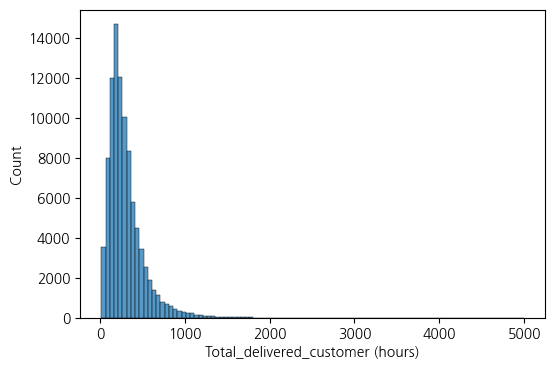

In [227]:
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(total_delivered_hour, bins=100)

ax.set_xlabel("Total_delivered_customer (hours)")
ax.set_ylabel("Count")
plt.show()

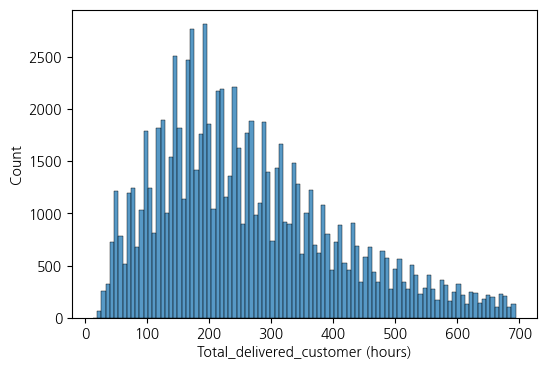

In [228]:
Q1 = total_delivered_hour.quantile(0.25)
Q3 = total_delivered_hour.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 이상치 제거
total_delivered_filtered = total_delivered_hour[(total_delivered_hour >= lower) & (total_delivered_hour <= upper)]

fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(total_delivered_filtered, bins=100, ax=ax)

ax.set_xlabel("Total_delivered_customer (hours)")
ax.set_ylabel("Count")
plt.show()

#### 예상 배송 기간과의 차이

In [206]:
# 예상 배송 날짜보다 빠르게 배송된 비율
sum(orders_final['order_delivered_customer_date'] < orders_final['order_estimated_delivery_date']) / len(orders_final)

0.9198273105212664

In [217]:
es_del_early = orders_final[orders_final['order_delivered_customer_date'] < orders_final['order_estimated_delivery_date']]

es_del_early_hour = (es_del_early['order_estimated_delivery_date'] - es_del_early['order_delivered_customer_date']).dt.total_seconds() / 3600
es_del_early_hour.describe()

count    86289.000000
mean       310.567437
std        173.883659
min          0.001389
25%        191.540556
50%        295.442778
75%        407.552778
max       3504.386944
dtype: float64

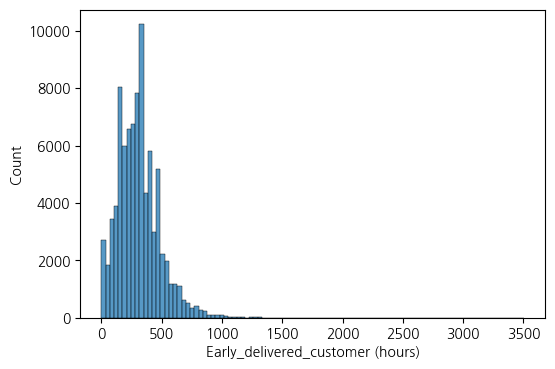

In [218]:
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(es_del_early_hour, bins=100)

ax.set_xlabel("Early_delivered_customer (hours)")
ax.set_ylabel("Count")
plt.show()

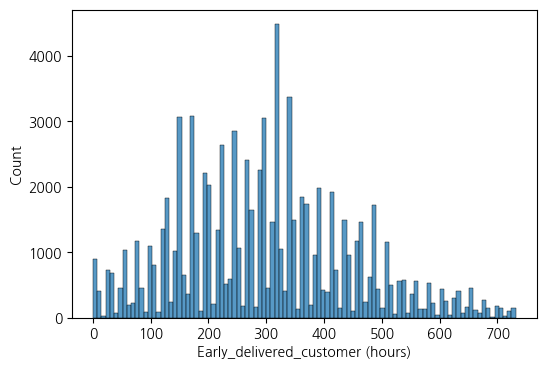

In [219]:
Q1 = es_del_early_hour.quantile(0.25)
Q3 = es_del_early_hour.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 이상치 제거
es_del_early_filtered = es_del_early_hour[(es_del_early_hour >= lower) & (es_del_early_hour <= upper)]

fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(es_del_early_filtered, bins=100, ax=ax)

ax.set_xlabel("Early_delivered_customer (hours)")
ax.set_ylabel("Count")
plt.show()

In [207]:
# 예상 배송 날짜보다 늦게 배송된 비율
sum(orders_final['order_delivered_customer_date'] > orders_final['order_estimated_delivery_date']) / len(orders_final)

0.08017268947873361

In [221]:
es_del_late = orders_final[orders_final['order_delivered_customer_date'] > orders_final['order_estimated_delivery_date']]

es_del_late_hour = (es_del_late['order_delivered_customer_date'] - es_del_late['order_estimated_delivery_date']).dt.total_seconds() / 3600
es_del_late_hour.describe()

count    7521.000000
mean      226.675345
std       330.287317
min         0.060000
25%        44.531944
50%       138.823056
75%       282.531389
max      4535.401944
dtype: float64

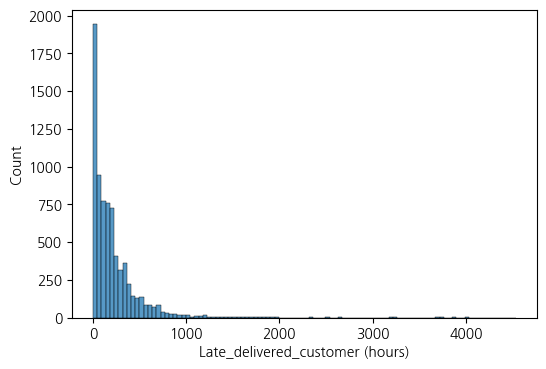

In [223]:
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(es_del_late_hour, bins=100)

ax.set_xlabel("Late_delivered_customer (hours)")
ax.set_ylabel("Count")
plt.show()

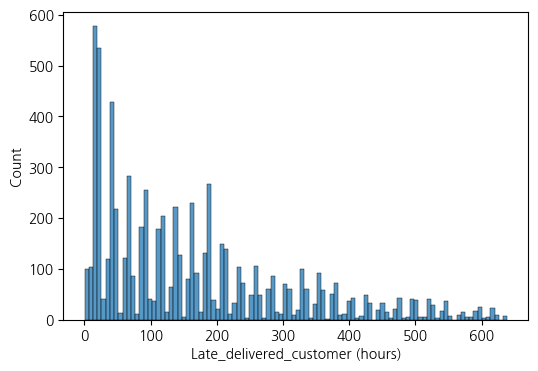

In [222]:
Q1 = es_del_late_hour.quantile(0.25)
Q3 = es_del_late_hour.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 이상치 제거
es_del_late_filtered = es_del_late_hour[(es_del_late_hour >= lower) & (es_del_late_hour <= upper)]

fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(es_del_late_filtered, bins=100, ax=ax)

ax.set_xlabel("Late_delivered_customer (hours)")
ax.set_ylabel("Count")
plt.show()

### order_items_final

In [199]:
order_items_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97357 entries, 0 to 97356
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       97357 non-null  object        
 1   shipping_limit_date            97357 non-null  datetime64[ns]
 2   price                          97357 non-null  float64       
 3   freight_value                  97357 non-null  float64       
 4   order_count                    97357 non-null  int64         
 5   product_id                     97357 non-null  object        
 6   product_category_name_english  97357 non-null  object        
 7   product_name_lenght            97357 non-null  float64       
 8   product_description_lenght     97357 non-null  float64       
 9   product_photos_qty             97357 non-null  float64       
 10  product_weight_g               97356 non-null  float64       
 11  product_length_

### order_payments_final

In [200]:
order_payments_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95924 entries, 0 to 95923
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              95924 non-null  object 
 1   payment_type          95924 non-null  object 
 2   payment_installments  95924 non-null  int32  
 3   payment_value         95924 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 2.6+ MB


### order_reviews_final

In [201]:
order_reviews_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94329 entries, 0 to 94328
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                94329 non-null  object        
 1   order_id                 94329 non-null  object        
 2   review_score             94329 non-null  int64         
 3   review_comment_title     11056 non-null  object        
 4   review_comment_message   38192 non-null  object        
 5   review_creation_date     94329 non-null  datetime64[ns]
 6   review_answer_timestamp  94329 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.0+ MB
